# Joyplot (ridgeline) diagnostic -- trend validation

Reproduces the ridgeline/joyplot panel *and* the global agreement map of
the trend-validation figure (originally
`como24_group5/code_final/1.5 trend_validation_clean.ipynb`, cells
`4fe4d484`/`bf824d1d` and `51e96620`) from the test datasets shipped under
`code_reviewed/test_data/`, as a regression check on `trend_sev_eval.py`'s
`uncertainty_range()`, `slopes_samples()`, `make_grid_ref_trend_ci()` and
`preprocess_ref_boot()` outputs.

Inputs:
- `agg_ic_ann_sev_GCMs_all_year_ERA5.nc` -- `uncertainty_range()` output:
  per-GCM bootstrap trend CI (`low_trend`/`up_trend`/`mean_trend`) at every
  grid cell, regridded onto the ERA5 target grid.
- `trend_ci_bootstrap_wcf_GWL1_ERA5.nc` -- `slopes_samples()` output:
  per (GCM, run, region) bootstrap trend CI (`slope_ci_low`/`slope_ci_up`/
  `slope_mean`) of the region-averaged severity series.
- `slopes_ic_ref_region_ERA5.nc` -- `preprocess_ref_boot()` output: the same
  regional bootstrap trend CI, but for the ERA5-observed reference severity
  (one row per region, no GCM/run) -- the red "observed" ridge.
- `grid_ic_ref.nc` -- `make_grid_ref_trend_ci()` output: the ERA5-observed
  reference trend CI (`low_trend`/`up_trend`/`mean_trend`) at *every grid
  cell* -- the observed-side analog of `agg_ic_ann_sev_GCMs_all_year_ERA5.nc`.
  Used in Section 3 as a cheap cross-check of `slopes_ic_ref_region_ERA5.nc`
  (spatially average its `mean_trend` per region, the same way Section 2
  does for the GCM file), and in Section 6 as the map's observed-side input
  -- both essentially free now that this file exists locally: earlier
  versions of this notebook reconstructed it from the ~3 GB raw
  `grid_ref_annual_sev_ERA5_all_year.nc` grid via a from-scratch per-cell
  bootstrap, which took 10-20 minutes and could run out of memory; that
  path is no longer needed now that `grid_ic_ref.nc` is available directly.
- `shapefiles/final_shp/ne_mix_adm0_adm1.shp` (one level up from
  `code_reviewed/`, not in `test_data/`) -- the land mask for Section 6's
  map, same file the original notebook used.

`slopes_samples()`/`preprocess_ref_boot()` deliberately only write the CI
summary, not the full 2000-draw bootstrap distribution (see the comment in
`trend_sev_eval.py`), so Section 4 below reconstructs an approximate
per-realization distribution from the summary stats to feed the ridgeline
-- see that section for the caveat. Sections 2 and 3 cross-check the two
regional-summary files (`trend_ci_bootstrap_wcf_GWL1_ERA5.nc` and
`slopes_ic_ref_region_ERA5.nc`) against their grid-level counterparts,
which do *not* rely on that approximation and are the more trustworthy
sanity checks.

**Kernel**: `Python (xesmf_env)` (has `xarray`/`joypy`/`matplotlib`/
`cartopy`/`geopandas`/`rioxarray`) -- note this notebook never imports
`trend_sev_eval` itself, since that module's `import xesmf` needs an
HPC-only ESMF build.

In [1]:
import os

# Import order matters on Windows: cartopy/geopandas/shapely/rioxarray each
# vendor their own GEOS/PROJ/GDAL DLLs, and importing joypy (pulls in scipy)
# first can shadow them with an incompatible version, breaking shapely with
# "DLL load failed ... procedure not found" later in the notebook. Importing
# the GIS stack first avoids that.
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import mapping
import rioxarray  # noqa: registers the .rio accessor used in Section 6

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.image as mpimg
from matplotlib.patheffects import withStroke
import joypy

CODE_REVIEWED_DIR = r"c:\Users\colin\Documents\These\Recherche\Compound_ER\code_reviewed"
TEST_DATA_DIR = os.path.join(CODE_REVIEWED_DIR, "test_data")

IC_GRID_PATH = os.path.join(TEST_DATA_DIR, "agg_ic_ann_sev_GCMs_all_year_ERA5.nc")
BOOT_PATH = os.path.join(TEST_DATA_DIR, "trend_ci_bootstrap_wcf_GWL1_ERA5.nc")
REF_BOOT_PATH = os.path.join(TEST_DATA_DIR, "slopes_ic_ref_region_ERA5.nc")
GRID_IC_REF_PATH = os.path.join(TEST_DATA_DIR, "grid_ic_ref.nc")
# ne_mix_adm0_adm1.shp / shp_re.shp (also used by config.SHAPEFILE_PATH /
# SHAPEFILE_PATH_LIGHT on the HPC) both stop at lat -55.63 -- no Antarctica
# polygon at all, which is why land_mask (Section 6) is False everywhere
# south of Tierra del Fuego regardless of the underlying trend data. Of the
# shapefiles under final_shp/, only ne_mix_adm0_adm1_greenland.shp reaches
# -90 (it has an explicit "Antarctica" feature) -- used here instead so
# Section 6/8's land mask isn't silently truncated at -55.6.
SHAPEFILE_PATH = os.path.join(CODE_REVIEWED_DIR, "..", "shapefiles", "final_shp", "ne_mix_adm0_adm1_greenland.shp")

OUT_DIR = os.path.join(CODE_REVIEWED_DIR, "aux_code", "diagnostics", "data")
os.makedirs(OUT_DIR, exist_ok=True)

# Same four regions as trend_sev_eval.py's slopes_samples()/preprocess_ref_boot()
REGIONS = [
    {"name": "Guiana Shield", "lat": [-10, 10], "lon": [-70, -50]},
    {"name": "Western U.S.", "lat": [35, 50],  "lon": [-125, -105]},
    {"name": "India",        "lat": [10, 30],  "lon": [70, 90]},
    {"name": "Kenya",        "lat": [-5, 5],   "lon": [33, 42]},
]

# Same map bounds as ax.set_extent(...) in fig1.py and fig3.py, so this
# diagnostic's map matches the published figures' cropping. Tightened from
# -58 to -48: Antarctica's nearest point is ~-60, and NZ/Australia's
# southernmost points (Stewart Island ~-47.3, Tasmania ~-43.6) stay clear.
MAP_EXTENT = [-180, 180, -48, 68]

N_SYNTH_SAMPLES = 2000  # samples drawn per realization for the ridgeline (see Section 4)
RNG_SEED = 0

# Same as config.EXCLUDE_GCM_RUN. Section 2's outlier check independently
# re-flags r3i1p1f1 in every region; inspecting its raw GWL1 input files
# directly (preprocessed_gwl1_aligned/EC-Earth3-Veg-LR/) confirmed why: its
# rsds file is truncated to 365 days instead of the expected 7305 (20
# years) that every other variable/run has -- a real data bug, not just
# high internal variability. config.EXCLUDE_GCM_RUN already excludes it
# from fig3.py's ensemble figures, but trend_sev_eval.uncertainty_range()/
# slopes_samples() didn't apply that exclusion (fixed alongside this
# notebook) -- so the two test-data files here were built from a run
# already known to be bad. It's dropped from both, right after loading,
# below.
EXCLUDE_GCM_RUN = {("EC-Earth3-Veg-LR", "r3i1p1f1")}

## 1. Load the two test datasets

In [2]:
ds_ic = xr.open_dataset(IC_GRID_PATH)
ds_boot = xr.open_dataset(BOOT_PATH)

# Drop excluded GCM/run realizations (see EXCLUDE_GCM_RUN above) before anything downstream uses them.
ic_keep = np.array([(g, r) not in EXCLUDE_GCM_RUN for g, r in zip(ds_ic.GCM.values, ds_ic.run.values)])
n_dropped = int((~ic_keep).sum())
if n_dropped:
    print(f"Dropping {n_dropped} excluded realization(s) from ds_ic: "
          f"{list(zip(ds_ic.GCM.values[~ic_keep], ds_ic.run.values[~ic_keep]))}")
ds_ic = ds_ic.isel(realization=ic_keep)

boot_keep = np.array([(g, r) not in EXCLUDE_GCM_RUN for g, r in zip(ds_boot.GCM.values, ds_boot.run.values)])
n_dropped = int((~boot_keep).sum())
if n_dropped:
    print(f"Dropping {n_dropped} excluded row(s) from ds_boot")
ds_boot = ds_boot.isel(realization=boot_keep)

print(ds_ic)
print()
print(ds_boot)

<xarray.Dataset> Size: 199MB
Dimensions:      (realization: 32, lat: 360, lon: 720)
Coordinates:
  * realization  (realization) int64 256B 0 1 2 3 4 5 6 ... 25 26 27 28 29 30 31
  * lat          (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
    number       int64 8B ...
    surface      float64 8B ...
  * lon          (lon) float64 6kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
Data variables:
    low_trend    (realization, lat, lon) float64 66MB ...
    up_trend     (realization, lat, lon) float64 66MB ...
    mean_trend   (realization, lat, lon) float64 66MB ...
    GCM          (realization) <U16 2kB 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'TaiESM1'
    run          (realization) <U9 1kB 'r1i1p1f1' 'r1i1p1f1' ... 'r1i1p1f1'
Attributes:
    regrid_method:  nearest_s2d

<xarray.Dataset> Size: 23kB
Dimensions:       (realization: 128)
Coordinates:
    region        (realization) <U13 7kB ...
    GCM           (realization) <U16 8kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'TaiESM1'
    run 

In [3]:
df_boot = ds_boot.to_dataframe().reset_index(drop=True)
df_boot["GCM"] = df_boot["GCM"].astype(str)
df_boot["run"] = df_boot["run"].astype(str)
df_boot["region"] = df_boot["region"].astype(str)

print(df_boot.groupby("region").size())
df_boot.head()

region
Guiana Shield    32
India            32
Kenya            32
Western U.S.     32
dtype: int64


,slope_ci_low,slope_ci_up,slope_mean,region,GCM,run
0,-0.005395,0.001626,-0.002214,Guiana Shield,ACCESS-CM2,r1i1p1f1
1,-0.000165,0.003946,0.001803,Western U.S.,ACCESS-CM2,r1i1p1f1
2,0.005237,0.009202,0.007260,India,ACCESS-CM2,r1i1p1f1
3,-0.006257,0.006113,0.000577,Kenya,ACCESS-CM2,r1i1p1f1
4,-0.010905,-0.004667,-0.007394,Guiana Shield,BCC-CSM2-MR,r1i1p1f1


## 2. Cross-check: gridded per-GCM trend vs. regional-mean bootstrap trend

`agg_ic_ann_sev_GCMs_all_year_ERA5.nc` (`uncertainty_range()`) fits the
trend independently at every grid cell, then we average `mean_trend` over
each region's lat/lon box. `trend_ci_bootstrap_wcf_GWL1_ERA5.nc`
(`slopes_samples()`) instead averages severity over the box *first* and
then fits one trend to that regional-mean series. The two aggregation
orders are not expected to match exactly, but for a well-behaved region
they should be strongly correlated across GCMs -- a large divergence would
flag a bug in one of the two pipelines.

In [4]:
rows = []
for r in REGIONS:
    box = ds_ic.sel(lat=slice(*r["lat"]), lon=slice(*r["lon"]))
    grid_mean = box.mean_trend.mean(dim=["lat", "lon"])
    for i in range(ds_ic.sizes["realization"]):
        rows.append({
            "region": r["name"],
            "GCM": str(ds_ic.GCM.values[i]),
            "run": str(ds_ic.run.values[i]),
            "grid_mean_trend": float(grid_mean.isel(realization=i).values),
        })
df_gridcheck = pd.DataFrame(rows)

df_cross = df_gridcheck.merge(df_boot, on=["region", "GCM", "run"], how="inner")
print(f"{len(df_cross)} / {len(df_boot)} bootstrap rows matched to a grid-based GCM/run/region")

corr_by_region = df_cross.groupby("region").apply(
    lambda d: d["grid_mean_trend"].corr(d["slope_mean"])
)
print("\nPearson correlation (grid_mean_trend vs. slope_mean) per region:")
print(corr_by_region)

128 / 128 bootstrap rows matched to a grid-based GCM/run/region



Pearson correlation (grid_mean_trend vs. slope_mean) per region:
region
Guiana Shield    0.998659
India            0.995242
Kenya            0.995659
Western U.S.     0.987970
dtype: float64


C:\Users\colin\AppData\Local\Temp\ipykernel_27432\874490200.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_by_region = df_cross.groupby("region").apply(


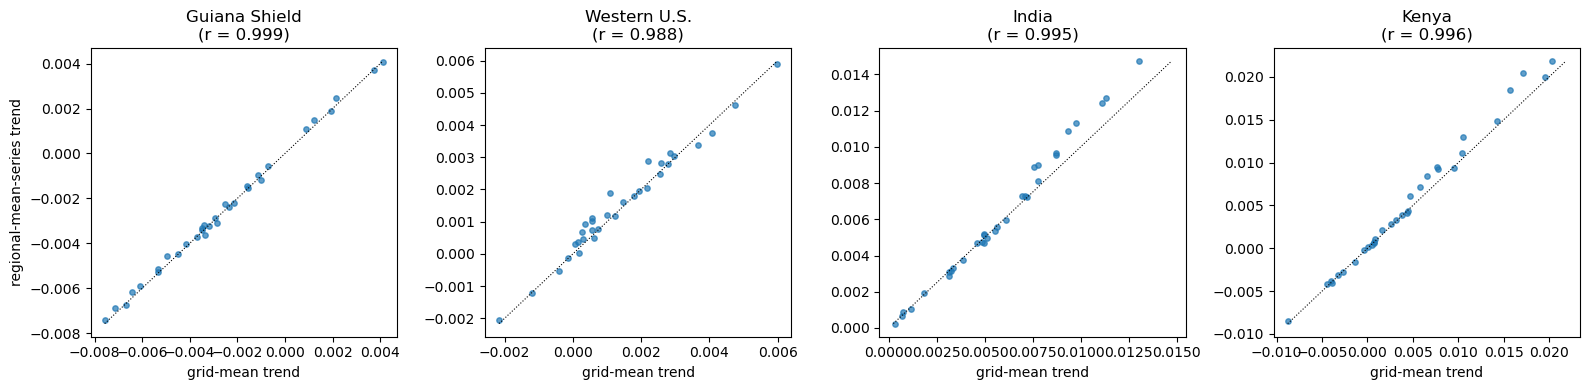

In [5]:
fig, axes = plt.subplots(1, len(REGIONS), figsize=(4 * len(REGIONS), 4), sharex=False, sharey=False)
for ax, r in zip(axes, REGIONS):
    d = df_cross[df_cross.region == r["name"]]
    ax.scatter(d["grid_mean_trend"], d["slope_mean"], s=15, alpha=0.7)
    lims = [min(d["grid_mean_trend"].min(), d["slope_mean"].min()),
            max(d["grid_mean_trend"].max(), d["slope_mean"].max())]
    ax.plot(lims, lims, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(f"{r['name']}\n(r = {corr_by_region[r['name']]:.3f})")
    ax.set_xlabel("grid-mean trend")
axes[0].set_ylabel("regional-mean-series trend")
fig.tight_layout()

### Flagging outlier GCM bootstraps

Within each region, flag GCM/run rows whose bootstrap CI is unusually
*wide* (`slope_ci_up - slope_ci_low`) or whose `slope_mean` sits unusually
far from the rest of that region's GCMs -- using a robust (median/MAD-based)
z-score so one or two genuine outliers don't just inflate the mean/std used
to judge them. These are exactly the ridges that visually stick out at the
top/bottom or look abnormally flat/spread-out in Section 5's joyplots.

In [6]:
def robust_z(x):
    """Median/MAD-based z-score (1.4826x scaling makes MAD ~= std for a normal dist)."""
    med = x.median()
    mad = (x - med).abs().median() * 1.4826
    return (x - med) / max(mad, 1e-12)


def flag_outlier_gcms(df, width_z_thresh=2.5, mean_z_thresh=2.5):
    df = df.copy()
    df["ci_width"] = df["slope_ci_up"] - df["slope_ci_low"]
    df["width_z"] = df.groupby("region")["ci_width"].transform(robust_z)
    df["mean_z"] = df.groupby("region")["slope_mean"].transform(robust_z)
    flagged = df[(df["width_z"] > width_z_thresh) | (df["mean_z"].abs() > mean_z_thresh)]
    return flagged.sort_values("width_z", ascending=False)


outlier_gcms = flag_outlier_gcms(df_boot)
cols = ["region", "GCM", "run", "slope_ci_low", "slope_ci_up", "slope_mean", "ci_width", "width_z", "mean_z"]
if outlier_gcms.empty:
    print("No outlier GCM bootstraps flagged.")
else:
    print(f"{len(outlier_gcms)} outlier GCM/run/region row(s) flagged:")
outlier_gcms[cols]

10 outlier GCM/run/region row(s) flagged:


,region,GCM,run,slope_ci_low,slope_ci_up,slope_mean,ci_width,width_z,mean_z
27,Kenya,CanESM5,r11i1p1f1,0.011181,0.043214,0.021883,0.032033,3.930013,2.278947
50,India,CanESM5,r14i1p1f1,0.011332,0.021541,0.014752,0.010209,3.284888,2.802709
31,Kenya,CanESM5,r11i1p2f1,0.010375,0.038209,0.020467,0.027834,3.089101,2.101973
46,India,CanESM5,r13i1p2f1,0.007489,0.017150,0.011316,0.009660,2.961362,1.787592
34,India,CanESM5,r12i1p1f1,0.002672,0.011963,0.007304,0.009291,2.743736,0.602038
17,Western U.S.,CanESM5,r10i1p1f1,0.003914,0.008861,0.005893,0.004947,0.510333,3.647542
89,Western U.S.,MPI-ESM1-2-LR,r2i1p1f1,0.002569,0.007195,0.004633,0.004626,0.190834,2.670948
60,Guiana Shield,GFDL-ESM4,r1i1p1f1,0.001439,0.007267,0.004078,0.005828,-0.537580,2.642236
93,Western U.S.,MPI-ESM1-2-LR,r3i1p1f1,-0.003842,-0.000158,-0.002047,0.003683,-0.746965,-2.506596
12,Guiana Shield,CNRM-CM6-1,r1i1p1f2,0.002256,0.005873,0.003734,0.003616,-1.548981,2.516411


On this test data, the top-flagged rows are `EC-Earth3-Veg-LR r3i1p1f1` in
all four regions (very wide CI and/or a `slope_mean` far below its region's
other GCMs) -- and that exact GCM/run pair is already in `config.py`'s
`EXCLUDE_GCM_RUN`, i.e. already known-bad and excluded from ensemble
figures elsewhere in the pipeline. That's a useful sanity check on this
detector: it re-discovers a documented exclusion from the bootstrap
summaries alone. `EC-Earth3-Veg-LR r2i1p1f1` (a *different* run of the same
GCM, not currently in `EXCLUDE_GCM_RUN`) is also flagged as an extreme
outlier in 3 of 4 regions -- worth a closer look at whether it should be
excluded too.

## 3. ERA5 observational reference

`slopes_ic_ref_region_ERA5.nc` (`preprocess_ref_boot()`) gives the observed
regional trend CI directly, from region-averaged series computed straight
off each GCM-threshold's raw reference grid. `grid_ic_ref.nc`
(`make_grid_ref_trend_ci()`) gives the same observed trend independently,
per grid cell instead of per region -- spatially averaging its `mean_trend`
over each region box (exactly like Section 2 does for the GCM grid file)
gives a second, independently-computed regional trend to compare against
`slopes_ic_ref_region_ERA5.nc`'s. The two aren't expected to match exactly
(`preprocess_ref_boot()` averages across GCM-threshold realizations *before*
the regional mean; `make_grid_ref_trend_ci()` averages them *before* fitting
the per-cell trend, then the cell-level trends get spatially averaged here
-- see `preprocess_ref_boot()`'s docstring for why these orders should
agree up to bootstrap noise), but a large divergence would flag a bug in
one of the two pipelines.

In [7]:
ds_ref_boot = xr.open_dataset(REF_BOOT_PATH)
df_ref = ds_ref_boot.to_dataframe().reset_index(drop=True)
df_ref["region"] = df_ref["region"].astype(str)
df_ref["GCM"] = "Reference"
df_ref["run"] = ""
print(df_ref)

   slope_ci_low  slope_ci_up  slope_mean         region        GCM run
0      0.009572     0.019033    0.013304  Guiana Shield  Reference    
1     -0.003261     0.001735   -0.000735   Western U.S.  Reference    
2      0.001093     0.006355    0.004042          India  Reference    
3     -0.005314     0.010820    0.003508          Kenya  Reference    


In [8]:
ds_grid_ic_ref = xr.open_dataset(GRID_IC_REF_PATH)

ref_gridcheck_rows = []
for r in REGIONS:
    box = ds_grid_ic_ref.mean_trend.sel(lat=slice(*r["lat"]), lon=slice(*r["lon"]))
    grid_mean = float(box.mean(skipna=True).values)
    ref_gridcheck_rows.append({"region": r["name"], "grid_slope_mean": grid_mean})
    print(f"{r['name']:15s} grid-based (grid_ic_ref.nc): mean={grid_mean:+.5f}")

df_ref_gridcheck = pd.DataFrame(ref_gridcheck_rows)
df_ref_compare = df_ref.merge(df_ref_gridcheck, on="region")
df_ref_compare["diff"] = df_ref_compare["slope_mean"] - df_ref_compare["grid_slope_mean"]
df_ref_compare[["region", "slope_mean", "grid_slope_mean", "diff", "slope_ci_low", "slope_ci_up"]]

Guiana Shield   grid-based (grid_ic_ref.nc): mean=+0.01199
Western U.S.    grid-based (grid_ic_ref.nc): mean=-0.00076
India           grid-based (grid_ic_ref.nc): mean=+0.00283
Kenya           grid-based (grid_ic_ref.nc): mean=+0.00372


,region,slope_mean,grid_slope_mean,diff,slope_ci_low,slope_ci_up
0,Guiana Shield,0.013304,0.011985,0.001319,0.009572,0.019033
1,Western U.S.,-0.000735,-0.000760,0.000024,-0.003261,0.001735
2,India,0.004042,0.002831,0.001212,0.001093,0.006355
3,Kenya,0.003508,0.003725,-0.000216,-0.005314,0.010820


In [9]:
# Fold the reference's grid-based cross-check into df_gridcheck under GCM="Reference",
# so Section 5's overlay-marker lookup (keyed on GCM/run) covers the reference ridge too.
df_gridcheck = pd.concat([
    df_gridcheck,
    df_ref_gridcheck.assign(GCM="Reference", run="", grid_mean_trend=df_ref_gridcheck["grid_slope_mean"])
                     [["region", "GCM", "run", "grid_mean_trend"]],
], ignore_index=True)

## 4. Reconstruct approximate per-realization bootstrap draws

`slopes_samples()`/`preprocess_ref_boot()` only write `slope_ci_low`/
`slope_ci_up`/`slope_mean` per row -- the full 2000-draw bootstrap
distribution is computed but not saved to disk, to keep the file small.
To still draw a ridgeline (which needs a distribution, not just three
numbers), we approximate each row's bootstrap slope distribution as
Gaussian: mean = `slope_mean`, and a std back-solved from the 95% CI
half-width (`slope_ci_up - slope_ci_low`) / (2 x 1.959964), then draw
synthetic samples from that Gaussian. This applies equally to the GCM rows
and the ERA5 reference row (Section 3) -- both files only store the same
three summary numbers.

This reproduces each ridge's location and width correctly (mean and CI are
exact) but not its true shape (skew, multimodality) -- treat the ridges
below as an approximate visualization of the CI, not the real bootstrap
distribution. Sections 2 and 3's cross-checks do not depend on this
approximation.

In [10]:
Z_95 = 1.959964


def synthesize_samples(df_region, n_samples=N_SYNTH_SAMPLES, seed=RNG_SEED):
    """Gaussian-approximation bootstrap draws per realization, from (mean, ci_low, ci_up)."""
    rng = np.random.default_rng(seed)
    out = []
    for real, row in df_region.iterrows():
        std = max((row.slope_ci_up - row.slope_ci_low) / (2 * Z_95), 1e-12)
        v = rng.normal(row.slope_mean, std, size=n_samples)
        out.append(pd.DataFrame({
            "region": row.region, "GCM": row.GCM, "run": row.run,
            "realization": real, "v": v,
        }))
    return pd.concat(out, ignore_index=True)

## 5. Joyplot (ridgeline) per region

One ridge per GCM realization plus one red ridge for the ERA5 observational
reference (Section 3), all ordered together by `slope_mean` (bottom =
lowest trend, top = highest). A triangular marker on each ridge shows the
matching independent grid-based cross-check value from Section 2 (GCMs) or
Section 3 (reference) -- it should sit close to the ridge's peak.

In [11]:
# Colorblind-safe styling (Okabe-Ito blue/vermillion), with the ERA5 ridge
# also set apart by a bold, wider, darker outline drawn on top -- so it is
# identifiable by line weight alone, not only by hue.
GCM_COLOR = "#0072B2"
REF_COLOR = "#D55E00"
REF_EDGE_COLOR = "#7A2E00"
GCM_LINEWIDTH = 0.6
REF_LINEWIDTH = 2.0


def plot_region_joyplot(region_name, df_boot, df_ref, df_gridcheck, x_range=None, figsize=(6, 8)):
    df_gcm = df_boot[df_boot.region == region_name]
    df_reference = df_ref[df_ref.region == region_name]
    df_region = pd.concat([df_gcm, df_reference], ignore_index=True)
    df_samples = synthesize_samples(df_region)

    order_map = (
        df_region[["GCM", "run", "slope_mean"]]
        .reset_index().rename(columns={"index": "realization"})
        .sort_values("slope_mean").reset_index(drop=True)
    )
    order_map["order"] = order_map.index
    df_samples = df_samples.merge(order_map[["realization", "order"]], on="realization")

    colors = [REF_COLOR if gcm == "Reference" else GCM_COLOR for gcm in order_map["GCM"]]

    fig, ax = plt.subplots(figsize=figsize)
    ticks = ["" for _ in order_map["order"]]
    axes = joypy.joyplot(
        data=df_samples, column="v", by="order", range_style="own",
        x_range=x_range, color=colors, overlap=1, linewidth=1,
        fade=False, alpha=0.6, ax=ax, labels=ticks,
    )
    axes_list = axes[1] if isinstance(axes, tuple) else axes
    for a in axes_list:
        a.axvline(0.0, color="black", linewidth=0.5, linestyle=":")
    # ERA5 ridge: bold, wider outline so it stands out without relying on hue.
    ref_order = int(order_map.loc[order_map["GCM"] == "Reference", "order"].iloc[0])
    for line in axes_list[ref_order].get_lines()[:-1]:
        line.set_linewidth(REF_LINEWIDTH)
        line.set_color(REF_EDGE_COLOR)

    gc = (
        df_gridcheck[df_gridcheck.region == region_name]
        .set_index(["GCM", "run"])["grid_mean_trend"]
    )
    for _, row in order_map.iterrows():
        key = (row["GCM"], row["run"])
        if key in gc.index:
            marker_color = "black" if row["GCM"] == "Reference" else REF_COLOR
            axes_list[int(row["order"])].plot(
                gc.loc[key], 0, marker="v", color=marker_color, markersize=5, clip_on=False,
            )

    axes_list[-1].set_xlabel("Trend in annual RED severity")
    axes_list[-1].set_title(region_name)
    return fig

C:\Users\colin\anaconda3\envs\xesmf_env\lib\site-packages\joypy\joyplot.py:413: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


Saved c:\Users\colin\Documents\These\Recherche\Compound_ER\code_reviewed\aux_code\diagnostics\data\joyplot_diagnosis_Guiana_Shield.png


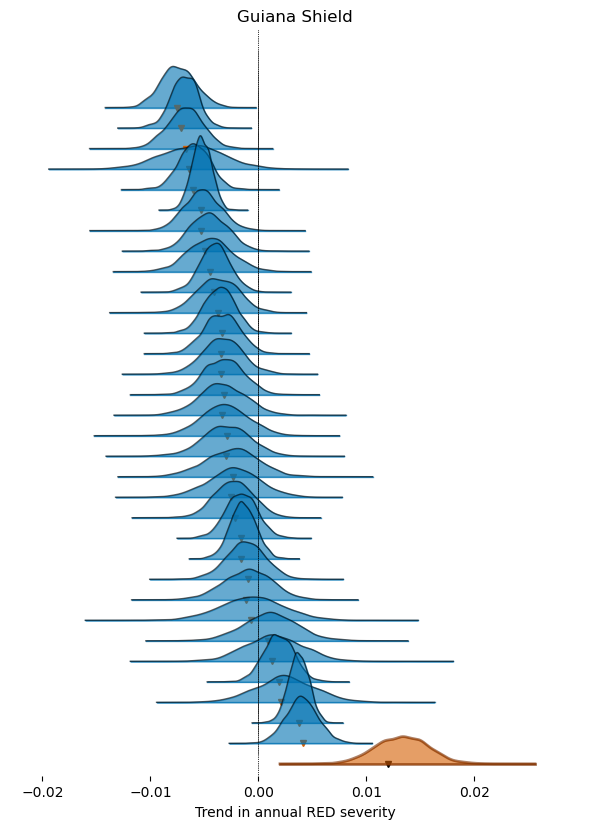

C:\Users\colin\anaconda3\envs\xesmf_env\lib\site-packages\joypy\joyplot.py:413: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


Saved c:\Users\colin\Documents\These\Recherche\Compound_ER\code_reviewed\aux_code\diagnostics\data\joyplot_diagnosis_Western_U.S..png


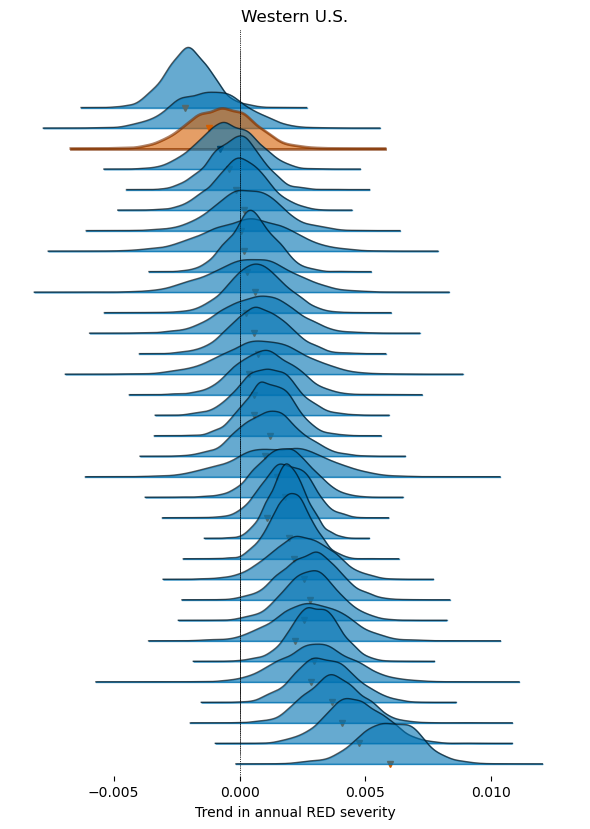

C:\Users\colin\anaconda3\envs\xesmf_env\lib\site-packages\joypy\joyplot.py:413: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


Saved c:\Users\colin\Documents\These\Recherche\Compound_ER\code_reviewed\aux_code\diagnostics\data\joyplot_diagnosis_India.png


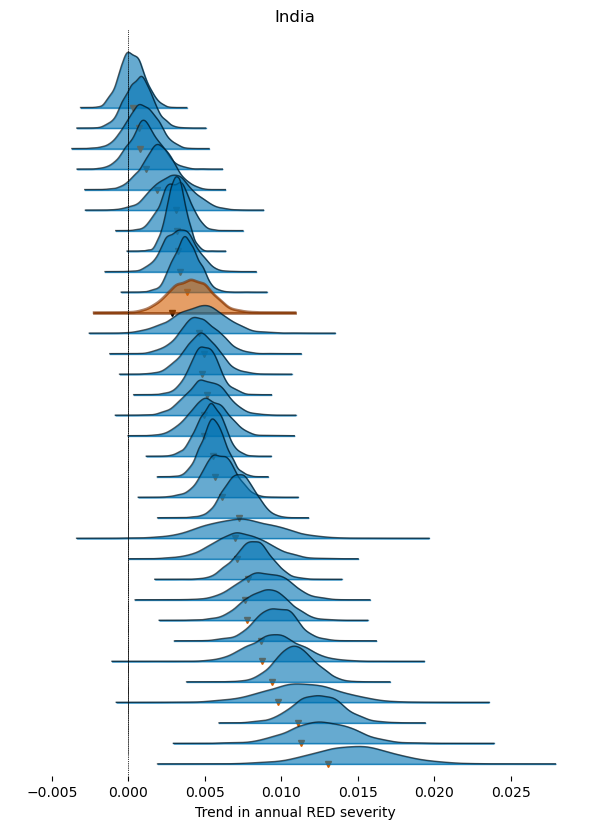

C:\Users\colin\anaconda3\envs\xesmf_env\lib\site-packages\joypy\joyplot.py:413: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


Saved c:\Users\colin\Documents\These\Recherche\Compound_ER\code_reviewed\aux_code\diagnostics\data\joyplot_diagnosis_Kenya.png


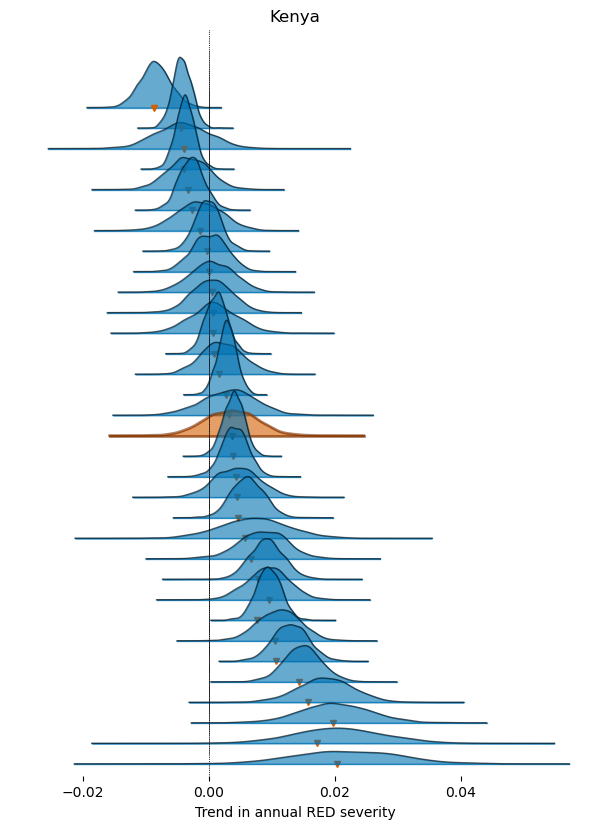

In [12]:
for r in REGIONS:
    fig = plot_region_joyplot(r["name"], df_boot, df_ref, df_gridcheck)
    out_path = os.path.join(OUT_DIR, f"joyplot_diagnosis_{r['name'].replace(' ', '_')}.png")
    fig.savefig(out_path, bbox_inches="tight", dpi=150)
    print(f"Saved {out_path}")
    plt.show()

## 6. Global map of agreement (+ combined figure with the joyplots)

The original notebook's fig2 panel (a): at every grid cell, the % of GCM
realizations whose projected trend CI (`agg_ic_ann_sev_GCMs_all_year_ERA5.nc`,
Section 1) overlaps the ERA5-observed trend CI (`grid_ic_ref.nc`, Section 3).

Land masking uses `shapefiles/final_shp/ne_mix_adm0_adm1.shp` (one level up
from `code_reviewed/`, the same file the original notebook used) --
`test_data/shapefile/test_land.shp` is a synthetic single-box stand-in for
a different diagnostic (`fig_persistent.py`'s) and isn't a real land mask,
so it isn't used here.

The final figure below combines the map with Section 5's four joyplot PNGs
underneath it (loading the files that cell already saved to `OUT_DIR`), one
combined panel per region box, the same layout as the original notebook's
`fig2_trend_validation.png`.

`fig1.py`/`fig3.py` crop their maps to `MAP_EXTENT = [-180, 180, -48, 68]`
via `ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())`, to drop Antarctica
from the figure. On `EqualEarth`'s curved meridians that's buggy: `set_extent`
clips to the smallest axis-aligned rectangle (in the projection's x/y plane)
containing the transformed box boundary, and that rectangle's right edge is
only calibrated to touch the true 180 deg meridian at the box's own latitude
bounds (-48/68) -- at other latitudes (e.g. Australia's, around 10-40 deg S)
it sits at a much smaller *effective* longitude (well under 180 deg E), so
it slices straight through any land that extends close to +/-180 deg at
those latitudes. Eastern Australia (Queensland, NSW, Tasmania) is exactly
that case: with `set_extent`, the map's east edge is a straight line
running through the middle of the country, well west of its real coast.

This notebook instead **masks** `within_pct` (and the shapefile boundaries)
to MAP_EXTENT's latitude band with `.where(...)`/`.cx[...]` -- see the cell
below and the one right before Section 6's figure -- and then calls
`ax_map.set_global()` instead of `set_extent`. `set_global()` uses the
projection's own uncropped boundary, which has no straight edges to clip
against, so nothing at a real longitude inside +/-180 deg gets cut off,
whatever its latitude; the poleward crop comes entirely from the data/shapes
being masked to NaN/dropped outside the band, not from the axes shape.
Antarctica's coastline outline still gets drawn (`ax_map.coastlines()` isn't
lat-filtered) but carries no data or country boundaries, so it reads as
empty background rather than content.

In [13]:
# Reuse the reference grid CI already loaded in Section 3 -- no bootstrap
# recomputation needed now that grid_ic_ref.nc is available directly.
ds_ref_ci = ds_grid_ic_ref

In [14]:
shapefile = gpd.read_file(SHAPEFILE_PATH)
# Greenland is in this "_greenland" shapefile only as a side effect of it
# also being the one file that has an Antarctica feature (see the config
# cell's comment) -- it isn't itself of interest here and its severity-trend
# agreement is noisy/uninteresting (ice sheet, sparse GCM coverage), so drop
# it from the land mask (and from the boundaries drawn later) same as any
# other excluded feature.
shapefile = shapefile[shapefile["ISO_A3"] != "GRL"].reset_index(drop=True)

land_da = ds_ref_ci.low_trend.copy()
land_da = land_da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
land_da = land_da.rio.write_crs("epsg:4326", inplace=True)
clipped = land_da.rio.clip(shapefile.geometry.apply(mapping), shapefile.crs, drop=False, all_touched=True)
land_mask = clipped.notnull()
print(f"land fraction of grid: {float(land_mask.mean()):.1%}")

ds_ref_masked = ds_ref_ci.where(land_mask)
ds_ic_masked = ds_ic.where(land_mask)

within = (
    (ds_ref_masked.low_trend < ds_ic_masked.up_trend) & (ds_ref_masked.up_trend > ds_ic_masked.low_trend)
).sum(dim="realization")
within = within.where(land_mask)
within_pct = within / ds_ic.sizes["realization"] * 100
# NOTE: within_pct is intentionally left at its full latitude range here
# (not cropped to MAP_EXTENT) -- Section 6's own map cell applies its
# -48/68 crop to a local copy instead of overwriting this shared variable,
# specifically so Section 8 (which wants a wider, -58/68 range to keep
# Patagonia in view) still has real data to select below -48. Cropping it
# here previously made Section 8's wider FINAL_MAP_LAT a no-op: anything
# south of -48 was already NaN'd out before Section 8 ever ran.

land fraction of grid: 34.4%


Saved c:\Users\colin\Documents\These\Recherche\Compound_ER\code_reviewed\aux_code\diagnostics\data\trend_validation_diagnosis_combined.png


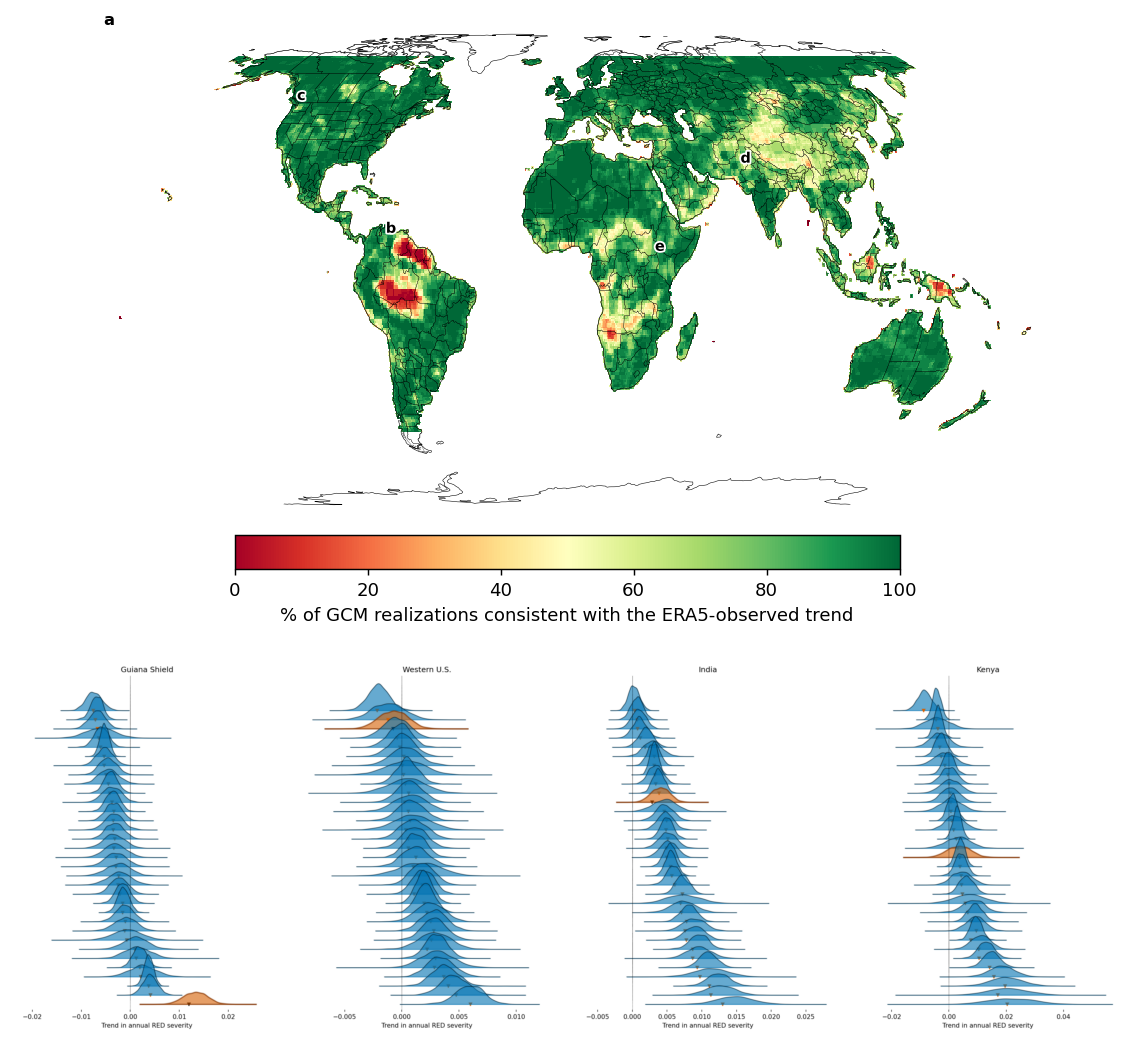

In [15]:
fig = plt.figure(figsize=(11, 10), dpi=130)
gs = GridSpec(2, len(REGIONS), height_ratios=[1.6, 1], hspace=0.08, wspace=0.05, figure=fig)

# --- Map (panel a) ---
ax_map = fig.add_subplot(gs[0, :], projection=ccrs.EqualEarth())

# Crop to MAP_EXTENT's latitude band on a local copy -- see the NOTE in the
# land-mask cell above: within_pct itself is kept at full latitude range so
# Section 8 can independently select a wider band; only this map's own view
# of it is cropped here.
_, _, lat_min, lat_max = MAP_EXTENT
within_pct_sec6 = within_pct.where((within_pct.lat >= lat_min) & (within_pct.lat <= lat_max))

m = within_pct_sec6.plot(
    ax=ax_map, cmap="RdYlGn", vmin=0, vmax=100, transform=ccrs.PlateCarree(),
    add_colorbar=True,
    cbar_kwargs={
        "label": "% of GCM realizations consistent with the ERA5-observed trend",
        "orientation": "horizontal", "pad": 0.05, "shrink": 0.6,
    },
)
shapefile_band = shapefile.cx[:, lat_min:lat_max]
shapefile_band.boundary.plot(ax=ax_map, edgecolor="black", linewidth=0.15, transform=ccrs.PlateCarree(), zorder=4)
ax_map.coastlines(linewidth=0.3)
ax_map.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
# set_global() (not ax_map.set_extent(MAP_EXTENT, ...)) -- the latitude crop
# is already applied by masking within_pct_sec6/shapefile_band above, so the
# axes can use the projection's true, uncropped boundary. set_extent's
# straight-edged rectangle cut off eastern Australia (see Section 6 markdown
# and the masking cell above); set_global() has no straight edges to clip
# against, so nothing at a real longitude inside +/-180 deg is lost.
ax_map.set_global()
ax_map.spines["geo"].set_visible(False)
# within_pct_sec6.plot() auto-titles from leftover scalar coords (spatial_ref/number/surface) -- drop it.
ax_map.set_title("")
ax_map.text(
    0.01, 1.01, "a", transform=ax_map.transAxes, ha="left", va="bottom",
    fontsize=9, fontweight="bold",
)

# --- Panel letters on the map, tying each region to its joyplot below ---
# (no bounding-box rectangle drawn around the region anymore, just the letter)
for i, r in enumerate(REGIONS):
    lon0, lon1 = r["lon"]
    lat1 = r["lat"][1]
    ax_map.text(
        lon0 + 0.5, lat1, chr(98 + i), fontsize=8, fontweight="bold",
        path_effects=[withStroke(linewidth=2, foreground="white")],
        transform=ccrs.PlateCarree(), zorder=5,
    )

# --- Joyplots (already saved by Section 5) as images along the bottom row ---
for i, r in enumerate(REGIONS):
    ax_img = fig.add_subplot(gs[1, i])
    img_path = os.path.join(OUT_DIR, f"joyplot_diagnosis_{r['name'].replace(' ', '_')}.png")
    img = mpimg.imread(img_path)
    ax_img.imshow(img, aspect="auto", interpolation="bilinear")
    ax_img.axis("off")

out_path = os.path.join(OUT_DIR, "trend_validation_diagnosis_combined.png")
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved {out_path}")
plt.show()

## 7. Notes

- If a region's correlation in Section 2 drops well below the others, or a
  marker lands far from its ridge's peak, check that `uncertainty_range()`
  and `slopes_samples()` (GCMs) or `make_grid_ref_trend_ci()` and
  `preprocess_ref_boot()` (reference) are using the same severity field,
  region boxes, and GCM/run ordering.
- If Section 3's `diff` column is large for a region, the realization/region
  mean-order swap in `preprocess_ref_boot()` may not be as harmless as its
  docstring argues for that region (e.g. a NaN-mask difference between
  realizations that breaks the "means over disjoint axes commute" argument).
- Section 5's joyplots and Section 6's map should agree qualitatively: a
  region whose reference ridge sits far outside the GCM cluster (e.g. an
  outlier "Reference" ridge) should show up as low agreement (red) in
  Section 6's map inside that region's box, and vice versa.
- To see the true (non-Gaussian) bootstrap shape, re-run
  `trend_sev_eval.slopes_samples()`/`preprocess_ref_boot()` with their
  discarded samples array wired to disk instead, for a handful of
  realizations.

## 8. Two-region publication figure (Guiana Shield + India), Robinson projection

A second version of Section 6's combined figure, styled after the original
`fig2_trend_validation.png` script: `ccrs.Robinson()` instead of
`EqualEarth`, and only the **two** regions used in that script's `regions`
list (`Guiana Shield`, `India`) rather than all four.

### One shared figure, not three stitched-together PNGs

The first version of this section built the map and each joyplot as
*separate* standalone figures (their own `figsize`/`dpi`), saved each to
its own PNG, then `imshow()`'d those PNGs into a combined `GridSpec` --
which is exactly why the panel widths, margins and font sizes didn't line
up: each sub-image was rasterized independently, at its own aspect ratio,
before being pasted into a cell that generally wasn't that same aspect
ratio.

The fix is to draw everything on **one** `fig`/`GridSpec` instead, so every
panel shares the same figure width, DPI and font-size constants
(`FS_PANEL_TITLE`/`FS_AXIS_LABEL`/`FS_TICK` below). The map (`ax_map2`,
`projection=ccrs.Robinson()`) is trivial to add as a normal `GridSpec`
subplot. The joyplots are not: `joypy.joyplot(..., ax=ax)` does **not**
embed into that one `ax`'s bounding box the way e.g. `imshow` would --
whenever it needs more than one ridge (i.e. always, here), it clears the
*entire containing figure* (`UserWarning: To output multiple subplots, the
figure containing the passed axes is being cleared`) and lays out its own
subplot grid across it, which would wipe out the map panel sharing that
figure. So Section 8 draws the ridgelines itself instead of calling into
`joypy`: `plot_ridgeline_embedded()` (next cell) computes a Gaussian KDE
per realization with `scipy.stats.gaussian_kde` and stacks them with
`ax.fill_between()`/`ax.plot()` directly on the given `GridSpec` axes --
implemented on a single explicit `ax` so it composes with the map in one
figure.

Two more style passes on top of that, back toward how Section 5's original
joyplots looked and read:
- **Own range + own-height normalization** ("more relief"): each ridge's
  KDE is now evaluated (and drawn) only over *its own* sample range, not a
  range shared across the whole panel -- so a narrow-CI GCM's ridge doesn't
  get artificially stretched thin across the full panel width, it's "cut"
  to where its distribution actually has mass. Each ridge's peak is also
  independently normalized to the same height (`step * overlap`, with
  `overlap=1` matching joypy's own default) rather than scaled relative to
  the panel's single tallest/narrowest realization -- otherwise a couple of
  very peaked, narrow-CI ridges dominate the shared height scale and every
  wide-CI ridge reads as nearly flat next to them. Independent per-ridge
  normalization is what gives every ridge comparable, visible relief.
- The grid-based cross-check "v" markers and the `region_name` text in each
  panel's label are both removed -- panels are now labeled with a bare
  letter ("b", "c") only, matching "a" on the map, and the per-region
  bounding-box rectangle is back on the map itself (the same rectangle
  Section 6 draws, removed then restored during iteration on this figure)
  to show where "b"/"c" are on the globe.

### Empirical (not Gaussian) ridges

Unlike Section 5, this figure's ridges are **not** built from Section 4's
Gaussian reconstruction. `plot_ridgeline_embedded()` reads the real 2000-draw
bootstrap trend samples from `region_trend_samples_ERA5.nc`
(`trend_sev_eval_wasserstein.region_empirical_trend_samples()`, the same file
`classify_gcm_trend_agreement.py`'s empirical composite plots), so skew and
multimodality show up as they are. The red ERA5 ridge pools every
realization's ERA5 draws (ERA5 is regridded onto each GCM's native grid
before bootstrapping, so each realization carries its own copy). Ridges are
ordered by their own sample mean. These samples come from a region mean on
each GCM's native grid, not from the ERA5-grid per-pixel CIs behind panel a's
map, so ridge positions can differ slightly from `slope_mean`.

### Greenland

`SHAPEFILE_PATH` (config cell) points at `ne_mix_adm0_adm1_greenland.shp`
rather than `ne_mix_adm0_adm1.shp` specifically to pick up its Antarctica
feature (see below) -- Greenland riding along in that same file is
incidental, and its severity-trend agreement is noisy/uninteresting (ice
sheet, sparse GCM coverage) rather than informative, so it's filtered out
of `shapefile` right after loading (`shapefile[shapefile["ISO_A3"] !=
"GRL"]`, Section 6's land-mask cell) -- dropped from the land mask *and*
from the boundaries drawn on the map, the same as any other excluded
feature, rather than left in to show up as a stray red patch.

### The "blank pixels" at the top/bottom of the map

Cropping a *curved* pseudo-cylindrical projection (Robinson here, same
family as Section 6's EqualEarth) to a latitude band with
`ax.set_extent([-180, 180, lat_min, lat_max], crs=PlateCarree())` leaves
visible **blank margins** above/below the data -- this is the same
geometric effect Section 6's markdown already describes for `set_extent`
cutting off eastern Australia, just showing up as empty padding instead of
a hard clip here: `set_extent` fits a straight-edged rectangle around the
projected boundary, and that boundary only reaches the rectangle's
top/bottom edge near the central meridian -- everywhere else the curve
sits *inside* the rectangle, leaving triangular/wedge-shaped blank strips
that are pure axes background, not missing data.

Because that blank margin is empty *canvas*, not missing *data*, the fix
is a **pixel-level post-crop** applied to the whole saved composite PNG
(`trim_blank_margins()`, a few cells down) rather than fiddling with
`set_extent`/latitude bounds: it removes/shrinks any image row that is
blank across the *full* image width. That is content-aware, not
latitude-aware -- it only ever removes rows with literally nothing drawn
on them anywhere in the row (map, joyplots, colorbar, labels), so it can
never clip real content (e.g. New Zealand, or the joyplots' own small
margins) no matter how close to an edge it sits. With this section's tuned
figure proportions, the natural spacing between the map and the joyplots
is already small enough that this crop only trims a modest, genuinely
blank margin above/below the map -- not an internal gap that needs
special-casing.

### Investigating South America's own blank-looking patches

Separately from the projection-margin issue above, southern South America
(Patagonia) shows small blank-looking gaps *inside* the landmass itself
in the map, which looks like missing data at first glance. The cell below
checks this directly against the source arrays: `land_mask & within_pct
.isnull()` is exactly zero everywhere, including in a Patagonia-only box --
so there is no missing/NaN data on land anywhere in this test dataset. The
zoomed, coastline-free render confirms what's actually there: those gaps
are real **ocean** grid cells (the Strait of Magellan, the Patagonian
channels/fjords) that the 0.5 deg land mask correctly resolves as
non-land, but which sit visually *inside* the landmass silhouette because
Patagonia's coastline is far more fragmented than a 0.5 deg grid can
represent. A second, purely cosmetic artifact compounds this: `ax.coastlines()`
draws a much finer-resolution coastline than the 0.5 deg data grid, so at
bays/inlets the fine coastline can carve a thin white sliver out of a
coarse land pixel even where that pixel's own value is valid -- confirmed
below by re-rendering the same Patagonia box with the coastlines/shapefile
overlays turned off, where the pattern of holes is unchanged (i.e. it's
the underlying grid resolution, not the overlay). Neither is a bug to fix
in the data pipeline.

Separately again: `ne_mix_adm0_adm1.shp` (like `shp_re.shp`, which is what
`config.SHAPEFILE_PATH` on the HPC actually points to for the production
`fig1.py`/`fig3.py`/etc. figures) has a bounding box that stops at
`lat=-55.63` with **no Antarctica feature at all**, so `land_mask` is
`False` everywhere south of Tierra del Fuego regardless of what the
underlying trend data says there -- not a `trend_sev_eval.py`/data issue,
the trend grids themselves are 100% non-null all the way to -90.
`ne_mix_adm0_adm1_greenland.shp` is the only shapefile under `final_shp/`
with an explicit `"Antarctica"` feature (bounds reach -90). This swap is
local to this notebook only -- it doesn't touch the HPC copy
`config.SHAPEFILE_PATH`/`SHAPEFILE_PATH_LIGHT` point to, so the production
figures are unaffected unless that config (and the underlying file on the
server) is updated separately.

Land-but-NaN pixels, globally: 0
Land-but-NaN pixels, southern South America box: 0
-> confirms the holes visible in Patagonia are not missing/NaN data.


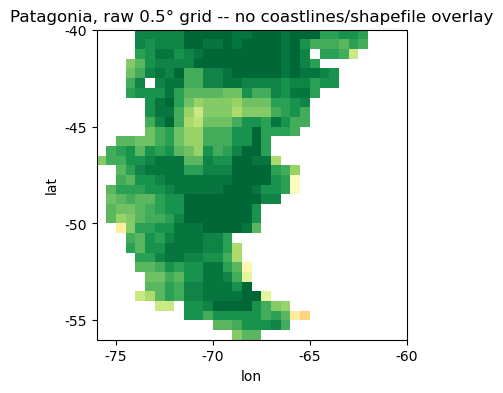

In [16]:
# --- South America blank-patch check: is it missing data? ---
mismatch = land_mask & within_pct.isnull()
print("Land-but-NaN pixels, globally:", int(mismatch.sum()))

sa_box = dict(lat=slice(-56, -30), lon=slice(-76, -53))
print("Land-but-NaN pixels, southern South America box:", int(mismatch.sel(**sa_box).sum()))
print("-> confirms the holes visible in Patagonia are not missing/NaN data.")

# Zoomed, coastline-free/shapefile-free render of the same box: if the holes
# are still there with every overlay turned off, they come from the 0.5 deg
# land mask/grid itself (real ocean cells), not from a rendering artifact.
patagonia = within_pct.sel(lat=slice(-56, -40), lon=slice(-76, -62))
fig_pat, ax_pat = plt.subplots(
    figsize=(4, 5), subplot_kw={"projection": ccrs.PlateCarree()}
)
patagonia.plot(ax=ax_pat, cmap="RdYlGn", vmin=0, vmax=100, transform=ccrs.PlateCarree(), add_colorbar=False)
ax_pat.set_title("Patagonia, raw 0.5° grid -- no coastlines/shapefile overlay")
#put lon lat 
ax_pat.set_xticks([-75, -70, -65, -60], crs=ccrs.PlateCarree())
ax_pat.set_yticks([-55, -50, -45, -40], crs=ccrs.PlateCarree())
ax_pat.set_xticklabels([-75, -70, -65, -60])
ax_pat.set_yticklabels([-55, -50, -45, -40])
plt.show()

In [17]:
from PIL import Image


def trim_blank_margins(img_path, out_path=None, white_thresh=248, max_internal_gap=18, edge_pad=6):
    """Remove/shrink blank (near-white, full image width) rows from a saved PNG.

    Leading/trailing runs of blank rows (e.g. the wedge-shaped empty margin
    a curved projection leaves above/below a lat-cropped map, see Section 8's
    markdown) are cut down to `edge_pad` rows. Blank runs *inside* the image
    (e.g. the gap between the southernmost land and a horizontal colorbar
    below it) are shrunk to `max_internal_gap` rows rather than removed
    outright, so the colorbar/labels stay visually separated from the map.
    A row only counts as blank if *every* pixel across the full width is
    near-white, so this can only ever remove rows with no content at all --
    it is content-aware, not latitude-aware, and can't clip real land
    (e.g. New Zealand) no matter how close to the edge it sits.
    """
    im = Image.open(img_path).convert("RGB")
    arr = np.array(im)
    row_is_blank = np.all(arr > white_thresh, axis=(1, 2))
    n = len(row_is_blank)
    if not (~row_is_blank).any():
        return img_path  # nothing but blank rows -- leave untouched

    first_content = int(np.argmax(~row_is_blank))
    last_content = n - 1 - int(np.argmax(~row_is_blank[::-1]))

    keep_mask = np.ones(n, dtype=bool)
    if first_content > edge_pad:
        keep_mask[: first_content - edge_pad] = False
    if last_content < n - 1 - edge_pad:
        keep_mask[last_content + 1 + edge_pad :] = False

    i = first_content
    while i <= last_content:
        if row_is_blank[i]:
            j = i
            while j <= last_content and row_is_blank[j]:
                j += 1
            run_len = j - i
            if run_len > max_internal_gap:
                drop_from = i + max_internal_gap // 2
                drop_to = j - (max_internal_gap - max_internal_gap // 2)
                if drop_to > drop_from:
                    keep_mask[drop_from:drop_to] = False
            i = j
        else:
            i += 1

    out_path = out_path or img_path
    Image.fromarray(arr[keep_mask]).save(out_path)
    print(f"{os.path.basename(img_path)}: {n} rows -> {int(keep_mask.sum())} rows")
    return out_path

In [18]:
from scipy.stats import gaussian_kde

# Real (non-Gaussian) bootstrap trend draws per realization/region, from
# trend_sev_eval_wasserstein.region_empirical_trend_samples() -- the same file
# classify_gcm_trend_agreement.py's empirical composite figure plots. Unlike
# Section 4's synthesize_samples(), nothing is reconstructed from a CI here.
REGION_SAMPLES_PATH = os.path.join(TEST_DATA_DIR, "region_trend_samples_ERA5.nc")
ds_region_samples = xr.open_dataset(REGION_SAMPLES_PATH)
rs_keep = np.array([(g, r) not in EXCLUDE_GCM_RUN
                    for g, r in zip(ds_region_samples.GCM.values, ds_region_samples.run.values)])
ds_region_samples = ds_region_samples.isel(realization=rs_keep)


def empirical_samples(ds_samples, region_name):
    """Long-format (GCM, run, v) draws for one region: one group per GCM
    realization (gcm_trend_samples), plus one "Reference" group pooling every
    realization's ERA5 draws (ref_trend_samples). ERA5 is regridded onto each
    GCM's native grid before bootstrapping, so each realization carries its own
    slightly different ERA5 copy -- pooling them gives one reference ridge that
    includes that regridding spread instead of picking one realization's copy.
    """
    sub = ds_samples.sel(region=region_name)
    parts = [
        pd.DataFrame({"GCM": str(sub.GCM.values[i]), "run": str(sub.run.values[i]),
                      "v": sub.gcm_trend_samples.isel(realization=i).values})
        for i in range(sub.sizes["realization"])
    ]
    parts.append(pd.DataFrame({"GCM": "Reference", "run": "",
                               "v": sub.ref_trend_samples.values.ravel()}))
    df = pd.concat(parts, ignore_index=True)
    return df[np.isfinite(df["v"])]

# Font sizes/letter style matched to fig1.py's convention (its main map+region
# figure, ~line 513-604) rather than invented ad hoc:
#   - map's own panel letter ("a"): ax.annotate(f"$\mathbf{{a}}$",
#     xy=(0.02, 1.02), xycoords="axes fraction", fontsize=7,
#     path_effects=[withStroke(linewidth=1.5, foreground="white")])
#   - on-map region-box letters ("b"/"c"): plain bold text (not LaTeX),
#     xy in PlateCarree data coords near the box's top-left corner,
#     fontsize=6, path_effects=[withStroke(linewidth=2, foreground="white")]
#     -- a white halo around the glyph, not a filled bbox behind it.
#   - per-panel letters on separate subplots (fig1.py's per-region time
#     series, our joyplot panels): f"$\mathbf{{b}}$" in axes-fraction coords,
#     fontsize=6, no path_effects (plain background, a halo isn't needed).
#   - axis tick labels/axis labels: fontsize=5; colorbar label: fontsize=6,
#     colorbar ticks: fontsize=5.
FS_MAP_PANEL_LETTER = 7
FS_REGION_LETTER = 6
FS_JOYPLOT_LETTER = 6
FS_AXIS_LABEL = 5
FS_TICK = 5
FS_CBAR_LABEL = 6
FIG_WIDTH_IN = 5.6
FIG_HEIGHT_IN = 5.7

FINAL_REGIONS = [r for r in REGIONS if r["name"] in ("Guiana Shield", "India")]
FINAL_MAP_LAT = (-58, 68)


def plot_ridgeline_embedded(ax, region_name, letter, ds_samples, overlap=1.0, step=1.0,
                            q=(2.5, 97.5)):
    """Draw one region's ridgeline directly on `ax` (a GridSpec subplot).

    Not joypy: joypy.joyplot(..., ax=ax) clears the *whole* containing
    figure once it needs more than one ridge, which would wipe out the map
    panel sharing this figure (see Section 8's markdown). This reproduces
    joypy's `range_style="own"` look -- each ridge's KDE evaluated (and
    plotted) only over *its own* sample range rather than a range shared
    across the whole panel ("cut" to its own distribution, not stretched
    across the full x-axis), and each ridge's peak independently normalized
    to the same height (`step * overlap`) rather than scaled relative to
    the panel's single widest/narrowest realization -- so every ridge shows
    comparable relief regardless of how wide or narrow its CI is, instead
    of wide-CI ridges going nearly flat next to a sharp narrow one.

    Ridges are KDEs of the real bootstrap draws (empirical_samples()), not
    Section 4's Gaussian reconstruction, and are ordered by each draw set's
    own mean. Each ridge's KDE is fitted on all of its draws but drawn only
    between its own `q` quantiles (default 2.5/97.5, i.e. its 95% bootstrap
    interval), so ridge extent reads directly as the trend CI.
    """
    df_samples = empirical_samples(ds_samples, region_name)

    order_map = (
        df_samples.groupby(["GCM", "run"], sort=False)["v"].mean()
        .rename("sample_mean").reset_index()
        .sort_values("sample_mean").reset_index(drop=True)
    )
    order_map["order"] = order_map.index
    df_samples = df_samples.merge(order_map[["GCM", "run", "order"]], on=["GCM", "run"])

    n = len(order_map)
    curves = []
    for _, row in order_map.iterrows():
        v = df_samples.loc[df_samples["order"] == row["order"], "v"].values
        lo, hi = np.percentile(v, q)
        xs_local = np.linspace(lo, hi, 250)
        dens = gaussian_kde(v)(xs_local)
        y = dens / dens.max() * step * overlap
        curves.append((xs_local, y))

    ax.axvline(0.0, color="black", linewidth=0.5, linestyle=":", zorder=0)
    for idx, row in order_map.iterrows():
        xs_local, y = curves[idx]
        baseline = idx * step
        if row["GCM"] == "Reference":
            # ERA5: bold, wider, darker outline, drawn above every GCM ridge.
            z = 4
            ax.fill_between(xs_local, baseline, baseline + y, color=REF_COLOR, alpha=0.3, linewidth=0, zorder=z)
            ax.plot(xs_local, baseline + y, color=REF_EDGE_COLOR, linewidth=REF_LINEWIDTH, zorder=z,
                    solid_capstyle="round")
        else:
            z = 2 + idx / n
            ax.fill_between(xs_local, baseline, baseline + y, color=GCM_COLOR, alpha=0.45, linewidth=0, zorder=z)
            ax.plot(xs_local, baseline + y, color=GCM_COLOR, linewidth=GCM_LINEWIDTH, zorder=z)

    ax.set_yticks([])
    ax.set_xlim(min(c[0].min() for c in curves), max(c[0].max() for c in curves))
    ax.set_ylim(0, (n - 1) * step + step * overlap * 1.15)
    for spine in ("left", "right", "top"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="x", labelsize=FS_TICK)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.set_xlabel("Trend in annual RED severity", fontsize=FS_AXIS_LABEL)
    ax.annotate(
        f"$\\mathbf{{{letter}}}$",
        xy=(0.02, 1.02), xycoords="axes fraction",
        ha="left", va="bottom", fontsize=FS_JOYPLOT_LETTER,
    )

trend_validation_diagnosis_2region.png: 963 rows -> 926 rows
Saved c:\Users\colin\Documents\These\Recherche\Compound_ER\code_reviewed\aux_code\diagnostics\data\trend_validation_diagnosis_2region.png


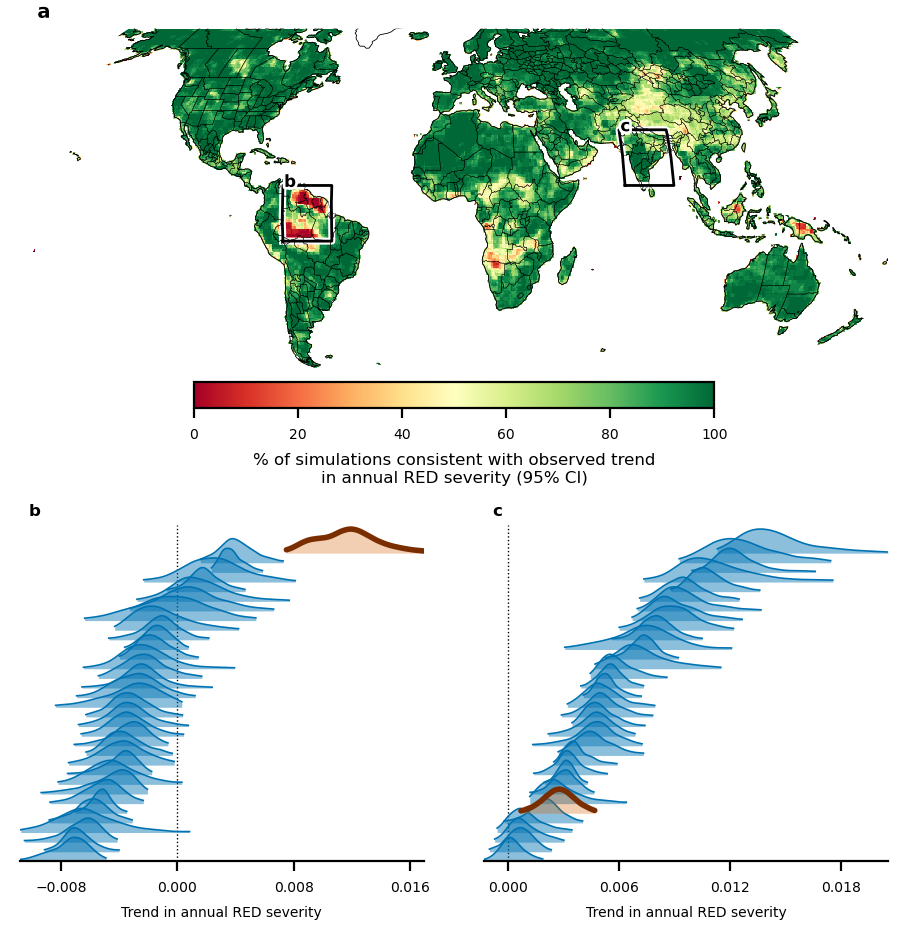

In [19]:
# --- One shared figure: Robinson map (top) + two embedded ridgelines (bottom) ---
within_final = within_pct.sel(lat=slice(*FINAL_MAP_LAT))

fig = plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN), dpi=200)
gs = GridSpec(2, len(FINAL_REGIONS), height_ratios=[1.1, 0.8], hspace=0.2, wspace=0.15, figure=fig)

ax_map2 = fig.add_subplot(gs[0, :], projection=ccrs.Robinson())
CBAR_LABEL = "% of simulations consistent with observed trend\nin annual RED severity (95% CI)"
m2 = within_final.plot(
    ax=ax_map2, cmap="RdYlGn", vmin=0, vmax=100, transform=ccrs.PlateCarree(),
    add_colorbar=True,
    cbar_kwargs={
        "label": CBAR_LABEL,
        "orientation": "horizontal", "pad": 0.02, "shrink": 0.6,
    },
)
m2.colorbar.ax.tick_params(labelsize=FS_TICK)
m2.colorbar.set_label(CBAR_LABEL, fontsize=FS_CBAR_LABEL)

shapefile.boundary.plot(ax=ax_map2, edgecolor="black", linewidth=0.15, zorder=4, transform=ccrs.PlateCarree())
ax_map2.coastlines(linewidth=0.3)
ax_map2.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
ax_map2.set_extent([-180, 180, *FINAL_MAP_LAT], crs=ccrs.PlateCarree())
ax_map2.set_title("")

# Map's own panel letter -- fig1.py's exact convention (LaTeX bold math,
# axes-fraction position, white halo via path_effects).
ax_map2.annotate(
    "$\\mathbf{a}$",
    xy=(0.02, 1.02), xycoords="axes fraction",
    ha="left", va="bottom", fontsize=FS_MAP_PANEL_LETTER,
    path_effects=[withStroke(linewidth=1.5, foreground="white")],
)
ax_map2.spines["geo"].set_visible(False)

# Region boxes on the map, each tagged with its matching letter -- fig1.py's
# on-map region-letter convention: plain bold text near the box's top-left
# corner (in PlateCarree data coords via `xycoords`), with a white halo
# (path_effects), not a filled bbox.
for i, region in enumerate(FINAL_REGIONS):
    lon0, lon1 = region["lon"]
    lat0, lat1 = region["lat"]
    ax_map2.plot(
        [lon0, lon1, lon1, lon0, lon0], [lat0, lat0, lat1, lat1, lat0],
        color="black", linewidth=1, transform=ccrs.PlateCarree(),
        path_effects=[withStroke(linewidth=2.5, foreground="white")],
    )
    ax_map2.annotate(
        chr(98 + i),
        xy=(lon0 + 0.5, lat1 - 0.5),
        xycoords=ccrs.PlateCarree()._as_mpl_transform(ax_map2),
        fontsize=FS_REGION_LETTER, fontweight="bold",
        path_effects=[withStroke(linewidth=2, foreground="white")],
        zorder=20,
    )

for i, r in enumerate(FINAL_REGIONS):
    ax_j = fig.add_subplot(gs[1, i])
    plot_ridgeline_embedded(ax_j, r["name"], chr(98 + i), ds_region_samples, overlap=2.5)

out_path = os.path.join(OUT_DIR, "trend_validation_diagnosis_2region.png")
fig.savefig(out_path, bbox_inches="tight", dpi=200)
plt.close(fig)
trim_blank_margins(out_path)
print(f"Saved {out_path}")

from IPython.display import Image as IPyImage
IPyImage(out_path)